In [1]:
"""
Find incomplete tasks with two-phase analysis - NOTEBOOK VERSION

Phase 1: Check pd/ and lgd/ result files to determine completion status
Phase 2: For missing tasks only, analyze log files to determine failure causes

Location: Run from scripts/Experiment1/ directory
Results: Located in results/experiment1/
"""

import sys
import re
import pickle
from pathlib import Path
from collections import defaultdict
from datetime import datetime

# Auto-detect project root from scripts/Experiment1/
def find_project_root():
    """Find project root by looking for config/ directory."""
    current = Path.cwd()
    
    # If we're in scripts/Experiment1/, go up 2 levels
    if current.name == 'Experiment1' and current.parent.name == 'scripts':
        return current.parent.parent
    
    # If we're in scripts/, go up 1 level
    if current.name == 'scripts':
        return current.parent
    
    # Try current directory
    if (current / 'config').exists():
        return current
    
    # Search upward
    for parent in current.parents:
        if (parent / 'config').exists():
            return parent
    
    raise FileNotFoundError("Could not find project root (no config/ directory found)")

PROJECT_ROOT = find_project_root()
print(f"Project root: {PROJECT_ROOT}")

# Add project to path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import project modules
from src.utils.config_reader import load_config
from src.utils.storage_handler import StorageHandler
from src.methods.method_config import NO_HPO_METHODS


def get_expected_tasks(config):
    """Build list of all expected tasks based on Experiment1 config."""
    tasks = []
    
    # PD tasks
    pd_datasets = [ds for ds, enabled in config['datasets']['pd'].items() if enabled]
    pd_methods = [m for m, enabled in config['methods']['pd'].items() if enabled]
    
    for dataset in pd_datasets:
        for method in pd_methods:
            tasks.append((dataset, method, 'pd', 'NO_HPO'))
            tasks.append((dataset, method, 'pd', 'HPO'))
    
    # LGD tasks
    lgd_datasets = [ds for ds, enabled in config['datasets']['lgd'].items() if enabled]
    lgd_methods = [m for m, enabled in config['methods']['lgd'].items() if enabled]
    
    for dataset in lgd_datasets:
        for method in lgd_methods:
            tasks.append((dataset, method, 'lgd', 'NO_HPO'))
            tasks.append((dataset, method, 'lgd', 'HPO'))
    
    return set(tasks)


def get_completed_tasks(experiment_dir):
    """Get list of completed tasks from result files."""
    completed = []
    
    for task_type in ['pd', 'lgd']:
        task_dir = experiment_dir / task_type
        
        if not task_dir.exists():
            print(f"Warning: Directory not found: {task_dir}")
            continue
        
        for result_file in task_dir.glob('*.pkl'):
            dataset = result_file.stem
            
            try:
                with open(result_file, 'rb') as f:
                    results = pickle.load(f)
                
                if 'NO_HPO' in results:
                    for method in results['NO_HPO'].keys():
                        completed.append((dataset, method, task_type, 'NO_HPO'))
                
                if 'HPO' in results:
                    for method in results['HPO'].keys():
                        completed.append((dataset, method, task_type, 'HPO'))
            
            except Exception as e:
                print(f"Warning: Could not read {result_file}: {e}")
    
    return set(completed)


def parse_errors_log_for_tasks(experiment_dir, missing_tasks):
    """Parse errors.log ONLY for tasks that are missing."""
    errors_log = experiment_dir / "logs" / "errors.log"
    failures = {}
    
    if not errors_log.exists():
        return failures
    
    missing_keys = {(d, m, h) for d, m, t, h in missing_tasks}
    
    try:
        with open(errors_log, 'r', encoding='utf-8', errors='ignore') as f:
            content = f.read()
        
        blocks = content.split('=' * 70)
        
        for block in blocks:
            if 'FAILED:' not in block:
                continue
            
            match = re.search(r'FAILED:\s+(.+?)/([\w_]+)/(NO_HPO|HPO)', block)
            if not match:
                continue
            
            dataset, method, hpo_mode = match.group(1), match.group(2), match.group(3)
            key = (dataset, method, hpo_mode)
            
            if key not in missing_keys:
                continue
            
            error_match = re.search(r'Error:\s*(.+?)(?=\nNode:|\Z)', block, re.DOTALL)
            time_match = re.search(r'Time:\s*(.+)', block)
            node_match = re.search(r'Node:\s*(.+)', block)
            
            error_text = error_match.group(1).strip() if error_match else 'Unknown'
            time_text = time_match.group(1).strip() if time_match else ''
            node_text = node_match.group(1).strip() if node_match else ''
            
            error_type = 'other'
            if 'CUDA out of memory' in error_text:
                error_type = 'cuda_oom'
            elif 'AssertionError' in error_text:
                error_type = 'assertion'
            elif not error_text or error_text == 'Unknown':
                error_type = 'unknown'
            
            failures[key] = {
                'error': error_text[:200],
                'type': error_type,
                'time': time_text,
                'node': node_text
            }
    
    except Exception as e:
        print(f"Warning: Could not parse errors.log: {e}")
    
    return failures


def find_timeout_tasks_for_missing(experiment_dir, missing_tasks):
    """Find SLURM timeouts ONLY for tasks that are missing."""
    slurm_logs = experiment_dir / "logs" / "slurm"
    timeouts = []
    
    if not slurm_logs.exists():
        return timeouts
    
    missing_keys = {(d, m, h) for d, m, t, h in missing_tasks}
    
    for err_file in slurm_logs.glob("*.err"):
        try:
            with open(err_file, 'r', encoding='utf-8', errors='ignore') as f:
                content = f.read()
            
            if 'TIME LIMIT' not in content and 'CANCELLED' not in content:
                continue
            
            out_file = err_file.with_suffix('.out')
            if not out_file.exists():
                continue
            
            with open(out_file, 'r', encoding='utf-8', errors='ignore') as f:
                out_content = f.read()
            
            match = re.search(
                r'Running task \d+:\s+(.+?)/([\w_]+)/(pd|lgd)/(NO_HPO|HPO)',
                out_content
            )
            
            if not match:
                dataset_match = re.search(r'Dataset:\s+(.+?)$', out_content, re.MULTILINE)
                method_match = re.search(r'Method:\s+([\w_]+)$', out_content, re.MULTILINE)
                task_match = re.search(r'Task type:\s+(pd|lgd)$', out_content, re.MULTILINE)
                hpo_match = re.search(r'HPO mode:\s+(NO_HPO|HPO)$', out_content, re.MULTILINE)
                
                if all([dataset_match, method_match, task_match, hpo_match]):
                    dataset = dataset_match.group(1).strip()
                    method = method_match.group(1).strip()
                    task_type = task_match.group(1).strip()
                    hpo_mode = hpo_match.group(1).strip()
                else:
                    continue
            else:
                dataset = match.group(1)
                method = match.group(2)
                task_type = match.group(3)
                hpo_mode = match.group(4)
            
            key = (dataset, method, hpo_mode)
            if key not in missing_keys:
                continue
            
            time_match = re.search(
                r'\[(\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})\.\d+\]',
                content
            )
            timestamp = time_match.group(1) if time_match else 'Unknown'
            
            node_match = re.search(r'ON ([\w\d]+)', content)
            node = node_match.group(1) if node_match else 'Unknown'
            
            timeouts.append({
                'dataset': dataset,
                'method': method,
                'task_type': task_type,
                'hpo_mode': hpo_mode,
                'time': timestamp,
                'node': node,
                'err_file': err_file.name
            })
        
        except Exception as e:
            continue
    
    return timeouts


def print_section_header(title):
    """Print a formatted section header."""
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def print_subsection_header(title):
    """Print a formatted subsection header."""
    print(f"\n{title}")
    print("-" * 70)


def group_by_method(items, key_func):
    """Group items by method/hpo_mode."""
    grouped = defaultdict(list)
    for item in items:
        key = key_func(item)
        grouped[key].append(item)
    return grouped


# ============================================================
# MAIN ANALYSIS
# ============================================================

print("Loading Experiment1 configuration...")
config = load_config("Experiment1")

storage = StorageHandler("experiment1")
experiment_dir = storage.get_experiment_path()

if not experiment_dir.exists():
    print(f"\n❌ ERROR: Experiment directory not found: {experiment_dir}")
    print("Have you run any tasks yet?")
else:
    print_section_header("EXPERIMENT 1 - COMPLETION STATUS")
    print(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Results: {experiment_dir}")
    
    # ============================================================
    # PHASE 1: CHECK RESULT FILES ONLY
    # ============================================================
    print_section_header("PHASE 1: CHECKING RESULT FILES")
    print("\n📊 Analyzing pd/ and lgd/ directories...")
    
    expected = get_expected_tasks(config)
    completed = get_completed_tasks(experiment_dir)
    missing = expected - completed
    
    total_expected = len(expected)
    total_completed = len(completed)
    total_missing = len(missing)
    completion_rate = (total_completed / total_expected * 100) if total_expected > 0 else 0
    
    print_section_header("SUMMARY STATISTICS")
    
    print(f"\nTotal expected tasks:  {total_expected:,}")
    print(f"Completed tasks:       {total_completed:,} ({completion_rate:.1f}%)")
    print(f"Missing tasks:         {total_missing:,} ({100-completion_rate:.1f}%)")
    
    # Break down by task type
    pd_expected = {t for t in expected if t[2] == 'pd'}
    pd_completed = {t for t in completed if t[2] == 'pd'}
    lgd_expected = {t for t in expected if t[2] == 'lgd'}
    lgd_completed = {t for t in completed if t[2] == 'lgd'}
    
    print(f"\nBy task type:")
    print(f"  PD:  {len(pd_completed):,}/{len(pd_expected):,} "
          f"({len(pd_completed)/len(pd_expected)*100:.1f}%)")
    print(f"  LGD: {len(lgd_completed):,}/{len(lgd_expected):,} "
          f"({len(lgd_completed)/len(lgd_expected)*100:.1f}%)")
    
    # Break down by HPO mode
    no_hpo_expected = {t for t in expected if t[3] == 'NO_HPO'}
    no_hpo_completed = {t for t in completed if t[3] == 'NO_HPO'}
    hpo_expected = {t for t in expected if t[3] == 'HPO'}
    hpo_completed = {t for t in completed if t[3] == 'HPO'}
    
    print(f"\nBy HPO mode:")
    print(f"  NO_HPO: {len(no_hpo_completed):,}/{len(no_hpo_expected):,} "
          f"({len(no_hpo_completed)/len(no_hpo_expected)*100:.1f}%)")
    print(f"  HPO:    {len(hpo_completed):,}/{len(hpo_expected):,} "
          f"({len(hpo_completed)/len(hpo_expected)*100:.1f}%)")
    
    if not missing:
        print_section_header("✅ ALL TASKS COMPLETED!")
        print("\n🎉 Experiment 1 has finished successfully!")
        print(f"   Total tasks completed: {total_completed:,}/{total_expected:,}")
        print("\n" + "=" * 70)
    else:
        # Show missing tasks grouped by method
        print_section_header(f"MISSING TASKS ({total_missing:,})")
        
        missing_list = sorted(missing, key=lambda x: (x[1], x[3], x[2], x[0]))
        grouped = group_by_method(missing_list, lambda x: f"{x[1]}/{x[3]}")
        
        for method_mode in sorted(grouped.keys()):
            tasks = grouped[method_mode]
            print_subsection_header(f"{method_mode} ({len(tasks)} tasks)")
            
            pd_tasks = [t for t in tasks if t[2] == 'pd']
            lgd_tasks = [t for t in tasks if t[2] == 'lgd']
            
            if pd_tasks:
                datasets = sorted([t[0] for t in pd_tasks])
                print(f"  PD ({len(pd_tasks)}): {', '.join(datasets)}")
            
            if lgd_tasks:
                datasets = sorted([t[0] for t in lgd_tasks])
                print(f"  LGD ({len(lgd_tasks)}): {', '.join(datasets)}")
        
        # ============================================================
        # PHASE 2: ANALYZE LOGS FOR MISSING TASKS ONLY
        # ============================================================
        print_section_header("PHASE 2: ANALYZING FAILURE CAUSES")
        print("\n🔍 Checking log files for missing tasks only...")
        
        python_errors = parse_errors_log_for_tasks(experiment_dir, missing)
        timeouts = find_timeout_tasks_for_missing(experiment_dir, missing)
        
        timeout_keys = {(t['dataset'], t['method'], t['hpo_mode']) for t in timeouts}
        cuda_oom_keys = {k for k, v in python_errors.items() if v['type'] == 'cuda_oom'}
        assertion_keys = {k for k, v in python_errors.items() if v['type'] == 'assertion'}
        other_error_keys = {k for k, v in python_errors.items() 
                           if v['type'] not in ['cuda_oom', 'assertion']}
        
        missing_with_task = list(missing)
        
        timeout_missing = [m for m in missing_with_task if (m[0], m[1], m[3]) in timeout_keys]
        cuda_oom_missing = [m for m in missing_with_task if (m[0], m[1], m[3]) in cuda_oom_keys]
        assertion_missing = [m for m in missing_with_task if (m[0], m[1], m[3]) in assertion_keys]
        other_error_missing = [m for m in missing_with_task if (m[0], m[1], m[3]) in other_error_keys]
        unknown_missing = [m for m in missing_with_task 
                          if (m[0], m[1], m[3]) not in timeout_keys 
                          and (m[0], m[1], m[3]) not in cuda_oom_keys
                          and (m[0], m[1], m[3]) not in assertion_keys
                          and (m[0], m[1], m[3]) not in other_error_keys]
        
        print_section_header("FAILURE BREAKDOWN")
        
        print(f"\nCategorized failures:")
        print(f"  SLURM timeouts:      {len(timeout_missing):,}")
        print(f"  CUDA out of memory:  {len(cuda_oom_missing):,}")
        print(f"  Assertion errors:    {len(assertion_missing):,}")
        print(f"  Other Python errors: {len(other_error_missing):,}")
        print(f"  Unknown/Not started: {len(unknown_missing):,}")
        
        # Display each category
        if timeout_missing:
            print_section_header(f"⏱️  SLURM TIMEOUTS ({len(timeout_missing)} tasks)")
            grouped = group_by_method(timeout_missing, lambda x: f"{x[1]}/{x[3]}")
            for method_mode in sorted(grouped.keys()):
                tasks = grouped[method_mode]
                datasets = [f"{t[0]}/{t[2]}" for t in sorted(tasks)]
                print(f"\n{method_mode} ({len(tasks)}): {', '.join(datasets)}")
            print("\n💡 Solution: Use retry scripts with increased walltime/resources")
        
        if cuda_oom_missing:
            print_section_header(f"🔥 CUDA OUT OF MEMORY ({len(cuda_oom_missing)} tasks)")
            grouped = group_by_method(cuda_oom_missing, lambda x: f"{x[1]}/{x[3]}")
            for method_mode in sorted(grouped.keys()):
                tasks = grouped[method_mode]
                datasets = [f"{t[0]}/{t[2]}" for t in sorted(tasks)]
                print(f"\n{method_mode} ({len(tasks)}): {', '.join(datasets)}")
            print("\n💡 Solution: Move to A100 (40GB) or H100 (80GB) GPUs")
        
        if assertion_missing:
            print_section_header(f"⚠️  ASSERTION ERRORS ({len(assertion_missing)} tasks)")
            grouped = group_by_method(assertion_missing, lambda x: f"{x[1]}/{x[3]}")
            for method_mode in sorted(grouped.keys()):
                tasks = grouped[method_mode]
                datasets = [f"{t[0]}/{t[2]}" for t in sorted(tasks)]
                print(f"\n{method_mode} ({len(tasks)}): {', '.join(datasets)}")
            print("\n💡 Solution: Fix method_runner.py to force tune=False for NO_HPO methods")
        
        if other_error_missing:
            print_section_header(f"❌ OTHER PYTHON ERRORS ({len(other_error_missing)} tasks)")
            grouped = group_by_method(other_error_missing, lambda x: f"{x[1]}/{x[3]}")
            for method_mode in sorted(grouped.keys()):
                tasks = grouped[method_mode]
                datasets = [f"{t[0]}/{t[2]}" for t in sorted(tasks)]
                print(f"\n{method_mode} ({len(tasks)}): {', '.join(datasets)}")
            print(f"\n💡 Solution: Check {experiment_dir / 'logs' / 'errors.log'}")
        
        if unknown_missing:
            print_section_header(f"❓ UNKNOWN/NOT STARTED ({len(unknown_missing)} tasks)")
            
            # Special handling for problematic datasets
            base_model_tasks = [m for m in unknown_missing if 'base_model' in m[0]]
            if base_model_tasks:
                problem_datasets = set([m[0] for m in base_model_tasks])
                print(f"\n⚠️  WARNING: {len(base_model_tasks)} tasks for datasets: {', '.join(problem_datasets)}")
                print("   These datasets may be missing or corrupted!")
                print("   Investigate: Check if dataset files exist and can be loaded")
            
            grouped = group_by_method(unknown_missing, lambda x: f"{x[1]}/{x[3]}")
            for method_mode in sorted(grouped.keys()):
                tasks = grouped[method_mode]
                datasets = [f"{t[0]}/{t[2]}" for t in sorted(tasks)]
                print(f"\n{method_mode} ({len(tasks)}): {', '.join(datasets)}")
            print("\n💡 These tasks have no error logs - may not have started or currently running")
        
        print_section_header("📋 NEXT STEPS")
        print("\n1. Check for problematic datasets (if applicable)")
        print("2. Submit retry jobs: sbatch Experiment1_Retry_*.slurm")
        print("3. Monitor progress: squeue -u $USER")
        print("\n" + "=" * 70)

print("\n✅ Analysis complete!")

Project root: c:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit
Loading Experiment1 configuration...

EXPERIMENT 1 - COMPLETION STATUS
Generated: 2026-01-05 10:48:24
Results: C:\Users\U0152019\OneDrive - KU Leuven\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results\experiment1

PHASE 1: CHECKING RESULT FILES

📊 Analyzing pd/ and lgd/ directories...

SUMMARY STATISTICS

Total expected tasks:  1,148
Completed tasks:       1,104 (96.2%)
Missing tasks:         44 (3.8%)

By task type:
  PD:  831/840 (98.9%)
  LGD: 273/308 (88.6%)

By HPO mode:
  NO_HPO: 552/574 (96.2%)
  HPO:    552/574 (96.2%)

MISSING TASKS (44)

amformer/HPO (1 tasks)
----------------------------------------------------------------------
  PD (1): 0013.home_credit

autoint/HPO (1 tasks)
----------------------------------------------------------------------
  LGD (1): 0005.base_modelisation

autoint/NO_HPO (1 tasks)
---------------------------------------------------------------------

Loading configuration and results...


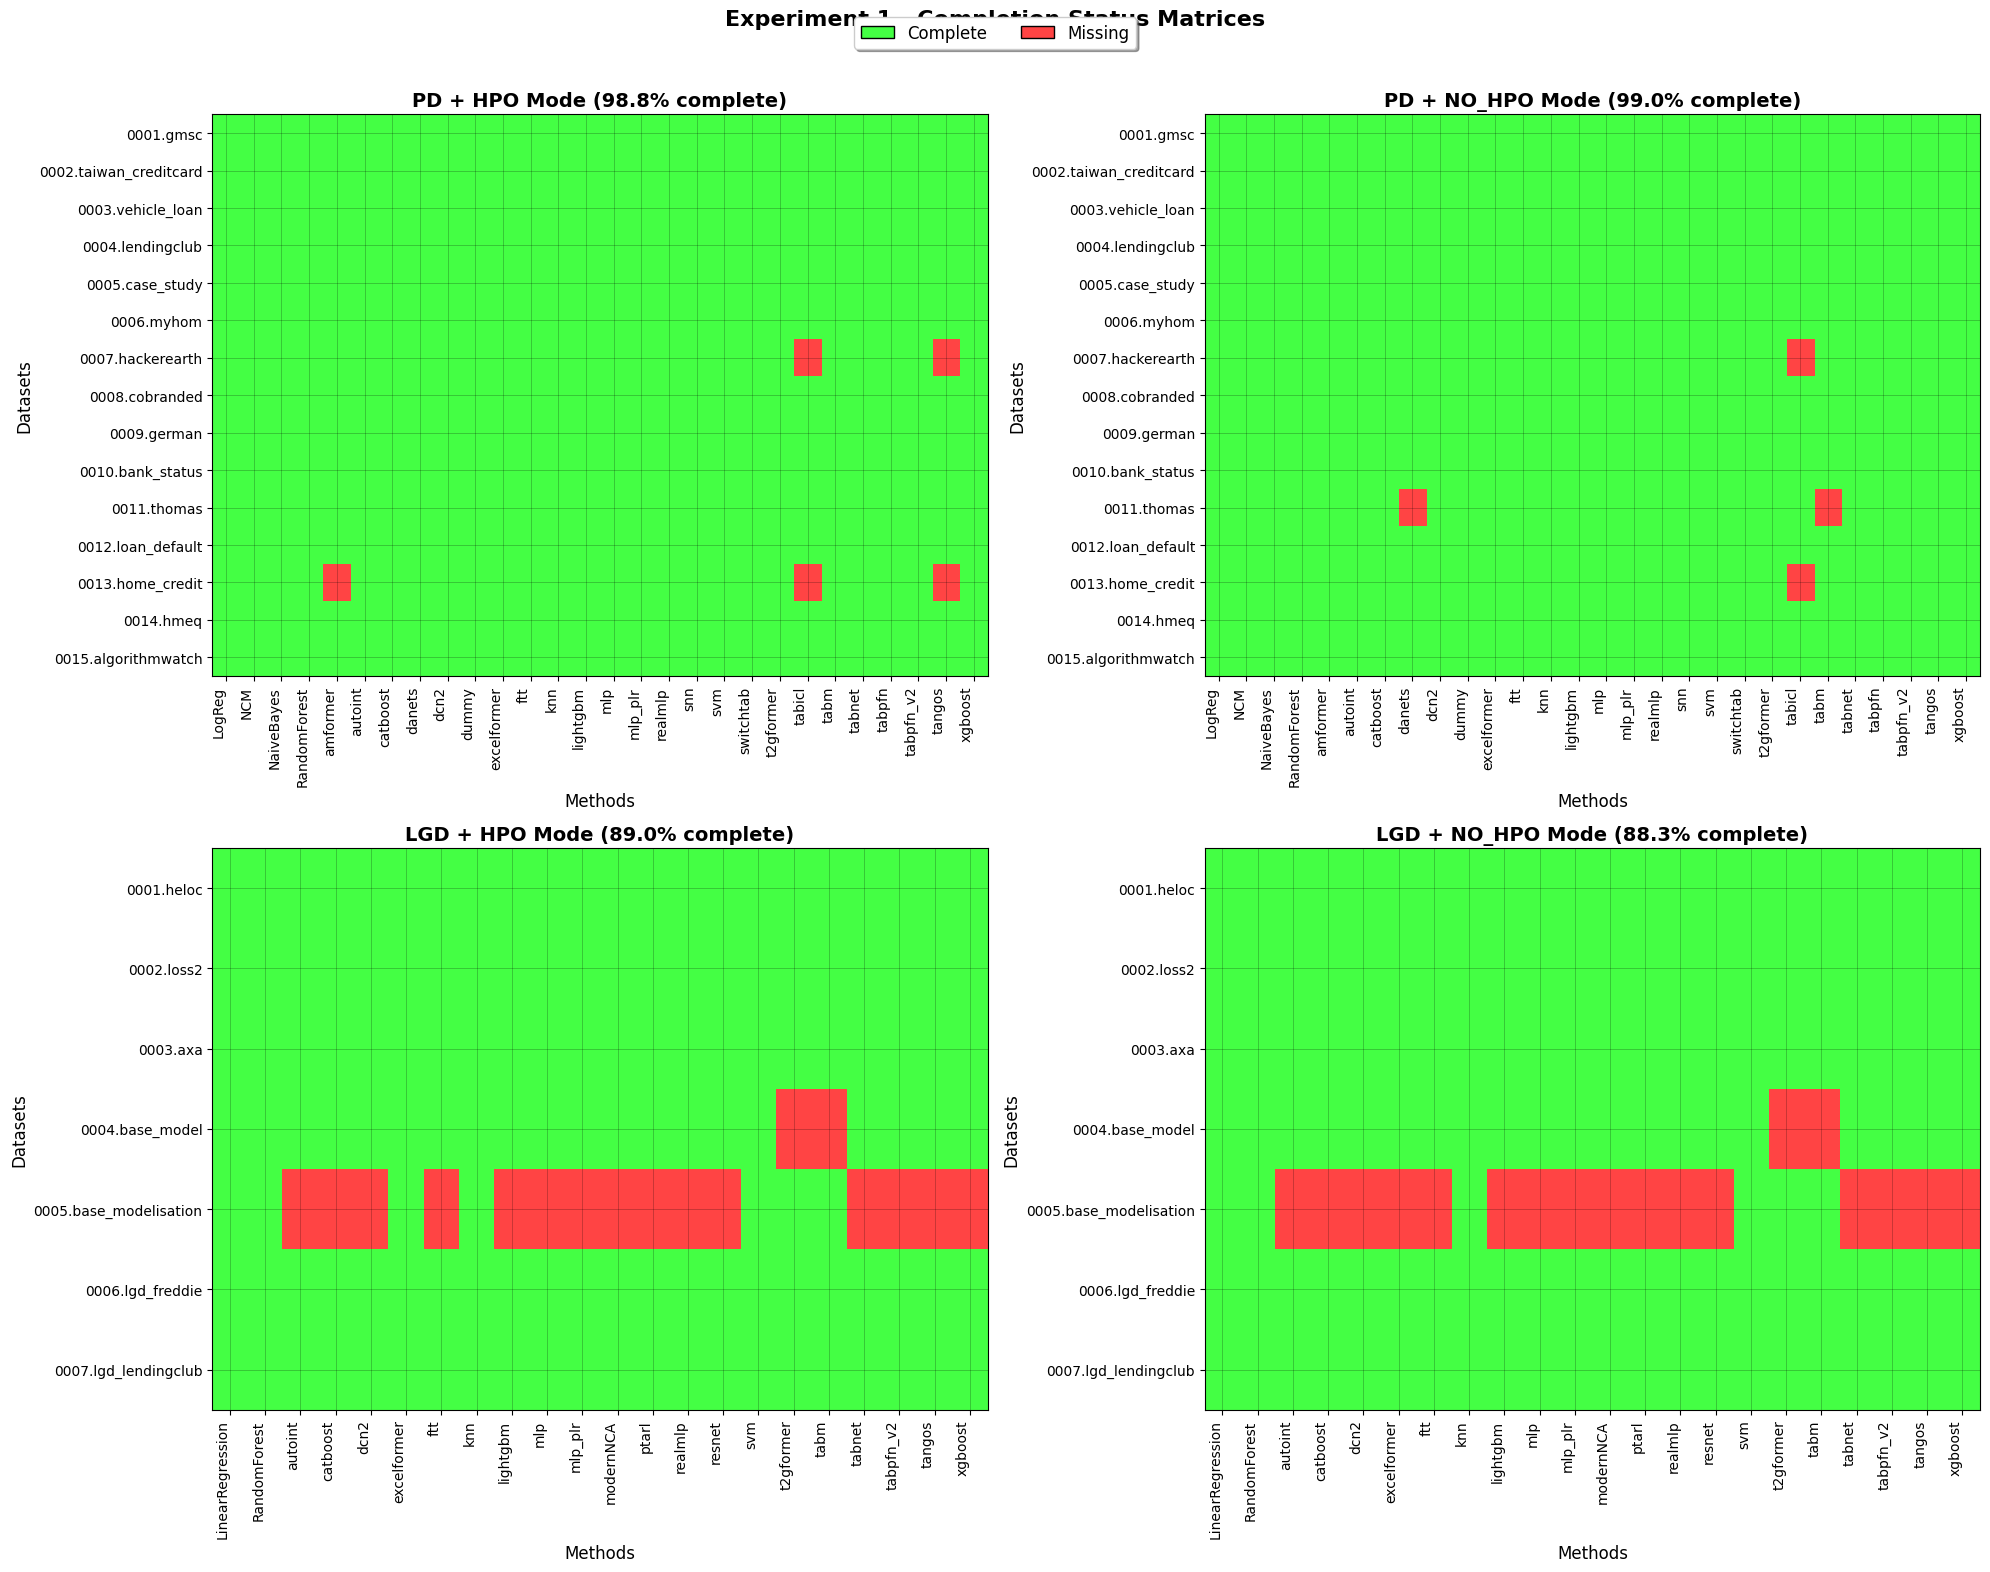


COMPLETION SUMMARY BY MODE

PD + HPO:     98.8% (415/420)
PD + NO_HPO:  99.0% (416/420)
LGD + HPO:    89.0% (137/154)
LGD + NO_HPO: 88.3% (136/154)

OVERALL:      96.2% (1104/1148)

METHODS WITH LOW COMPLETION RATES

PD Methods:
  tabicl         :  86.7% (26/30)
  tangos         :  93.3% (28/30)
  amformer       :  96.7% (29/30)
  danets         :  96.7% (29/30)
  tabm           :  96.7% (29/30)

LGD Methods:
  autoint        :  85.7% (12/14)
  catboost       :  85.7% (12/14)
  dcn2           :  85.7% (12/14)
  ftt            :  85.7% (12/14)
  lightgbm       :  85.7% (12/14)
  mlp            :  85.7% (12/14)
  mlp_plr        :  85.7% (12/14)
  modernNCA      :  85.7% (12/14)
  ptarl          :  85.7% (12/14)
  realmlp        :  85.7% (12/14)
  resnet         :  85.7% (12/14)
  t2gformer      :  85.7% (12/14)
  tabm           :  85.7% (12/14)
  tabnet         :  85.7% (12/14)
  tabpfn_v2      :  85.7% (12/14)
  tangos         :  85.7% (12/14)
  xgboost        :  85.7% (12/14)
  excelf

In [2]:
"""
Visualize completion status as 4 heatmap matrices.

Shows which dataset/method combinations are complete (green) or missing (red)
for each of the 4 task modes: PD/HPO, PD/NO_HPO, LGD/HPO, LGD/NO_HPO

Location: Run from scripts/Experiment1/ directory
"""

import sys
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Auto-detect project root from scripts/Experiment1/
def find_project_root():
    """Find project root by looking for config/ directory."""
    current = Path.cwd()
    
    if current.name == 'Experiment1' and current.parent.name == 'scripts':
        return current.parent.parent
    if current.name == 'scripts':
        return current.parent
    if (current / 'config').exists():
        return current
    
    for parent in current.parents:
        if (parent / 'config').exists():
            return parent
    
    raise FileNotFoundError("Could not find project root")

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config_reader import load_config
from src.utils.storage_handler import StorageHandler
from src.methods.method_config import NO_HPO_METHODS

print("Loading configuration and results...")

# Load config
config = load_config("Experiment1")

# Get experiment directory
storage = StorageHandler("experiment1")
experiment_dir = storage.get_experiment_path()

if not experiment_dir.exists():
    print(f"❌ ERROR: Experiment directory not found: {experiment_dir}")
else:
    # Get datasets and methods from config
    pd_datasets = sorted([ds for ds, enabled in config['datasets']['pd'].items() if enabled])
    pd_methods = sorted([m for m, enabled in config['methods']['pd'].items() if enabled])
    lgd_datasets = sorted([ds for ds, enabled in config['datasets']['lgd'].items() if enabled])
    lgd_methods = sorted([m for m, enabled in config['methods']['lgd'].items() if enabled])
    
    # Load completed tasks
    completed = set()
    for task_type in ['pd', 'lgd']:
        task_dir = experiment_dir / task_type
        if not task_dir.exists():
            continue
        
        for result_file in task_dir.glob('*.pkl'):
            dataset = result_file.stem
            try:
                with open(result_file, 'rb') as f:
                    results = pickle.load(f)
                
                if 'NO_HPO' in results:
                    for method in results['NO_HPO'].keys():
                        completed.add((dataset, method, task_type, 'NO_HPO'))
                
                if 'HPO' in results:
                    for method in results['HPO'].keys():
                        completed.add((dataset, method, task_type, 'HPO'))
            except:
                pass
    
    # Create 4 matrices
    def create_completion_matrix(datasets, methods, task_type, hpo_mode):
        """Create completion matrix for given task type and mode."""
        matrix = np.zeros((len(datasets), len(methods)))
        
        for i, dataset in enumerate(datasets):
            for j, method in enumerate(methods):
                if (dataset, method, task_type, hpo_mode) in completed:
                    matrix[i, j] = 1  # Green (complete)
                else:
                    matrix[i, j] = 0  # Red (missing)
        
        return matrix
    
    # Create matrices
    pd_hpo_matrix = create_completion_matrix(pd_datasets, pd_methods, 'pd', 'HPO')
    pd_no_hpo_matrix = create_completion_matrix(pd_datasets, pd_methods, 'pd', 'NO_HPO')
    lgd_hpo_matrix = create_completion_matrix(lgd_datasets, lgd_methods, 'lgd', 'HPO')
    lgd_no_hpo_matrix = create_completion_matrix(lgd_datasets, lgd_methods, 'lgd', 'NO_HPO')
    
    # Calculate completion rates
    def calc_completion_rate(matrix):
        total = matrix.size
        completed = np.sum(matrix)
        return (completed / total * 100) if total > 0 else 0
    
    pd_hpo_rate = calc_completion_rate(pd_hpo_matrix)
    pd_no_hpo_rate = calc_completion_rate(pd_no_hpo_matrix)
    lgd_hpo_rate = calc_completion_rate(lgd_hpo_matrix)
    lgd_no_hpo_rate = calc_completion_rate(lgd_no_hpo_matrix)
    
    # Create figure with 4 subplots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    fig.suptitle('Experiment 1 - Completion Status Matrices', fontsize=16, fontweight='bold')
    
    # Color scheme: red for missing (0), green for complete (1)
    cmap = plt.cm.colors.ListedColormap(['#ff4444', '#44ff44'])
    
    # Plot 1: PD + HPO
    ax1 = axes[0, 0]
    im1 = ax1.imshow(pd_hpo_matrix, cmap=cmap, aspect='auto', interpolation='nearest')
    ax1.set_title(f'PD + HPO Mode ({pd_hpo_rate:.1f}% complete)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Methods', fontsize=12)
    ax1.set_ylabel('Datasets', fontsize=12)
    ax1.set_xticks(range(len(pd_methods)))
    ax1.set_xticklabels(pd_methods, rotation=90, ha='right')
    ax1.set_yticks(range(len(pd_datasets)))
    ax1.set_yticklabels(pd_datasets)
    ax1.grid(True, which='both', color='black', linewidth=0.5, alpha=0.3)
    
    # Plot 2: PD + NO_HPO
    ax2 = axes[0, 1]
    im2 = ax2.imshow(pd_no_hpo_matrix, cmap=cmap, aspect='auto', interpolation='nearest')
    ax2.set_title(f'PD + NO_HPO Mode ({pd_no_hpo_rate:.1f}% complete)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Methods', fontsize=12)
    ax2.set_ylabel('Datasets', fontsize=12)
    ax2.set_xticks(range(len(pd_methods)))
    ax2.set_xticklabels(pd_methods, rotation=90, ha='right')
    ax2.set_yticks(range(len(pd_datasets)))
    ax2.set_yticklabels(pd_datasets)
    ax2.grid(True, which='both', color='black', linewidth=0.5, alpha=0.3)
    
    # Plot 3: LGD + HPO
    ax3 = axes[1, 0]
    im3 = ax3.imshow(lgd_hpo_matrix, cmap=cmap, aspect='auto', interpolation='nearest')
    ax3.set_title(f'LGD + HPO Mode ({lgd_hpo_rate:.1f}% complete)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Methods', fontsize=12)
    ax3.set_ylabel('Datasets', fontsize=12)
    ax3.set_xticks(range(len(lgd_methods)))
    ax3.set_xticklabels(lgd_methods, rotation=90, ha='right')
    ax3.set_yticks(range(len(lgd_datasets)))
    ax3.set_yticklabels(lgd_datasets)
    ax3.grid(True, which='both', color='black', linewidth=0.5, alpha=0.3)
    
    # Plot 4: LGD + NO_HPO
    ax4 = axes[1, 1]
    im4 = ax4.imshow(lgd_no_hpo_matrix, cmap=cmap, aspect='auto', interpolation='nearest')
    ax4.set_title(f'LGD + NO_HPO Mode ({lgd_no_hpo_rate:.1f}% complete)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Methods', fontsize=12)
    ax4.set_ylabel('Datasets', fontsize=12)
    ax4.set_xticks(range(len(lgd_methods)))
    ax4.set_xticklabels(lgd_methods, rotation=90, ha='right')
    ax4.set_yticks(range(len(lgd_datasets)))
    ax4.set_yticklabels(lgd_datasets)
    ax4.grid(True, which='both', color='black', linewidth=0.5, alpha=0.3)
    
    # Add legend
    legend_elements = [
        mpatches.Patch(facecolor='#44ff44', edgecolor='black', label='Complete'),
        mpatches.Patch(facecolor='#ff4444', edgecolor='black', label='Missing')
    ]
    fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
               ncol=2, fontsize=12, frameon=True, fancybox=True, shadow=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
    
    # Print summary statistics
    print("\n" + "=" * 70)
    print("COMPLETION SUMMARY BY MODE")
    print("=" * 70)
    print(f"\nPD + HPO:     {pd_hpo_rate:.1f}% ({int(np.sum(pd_hpo_matrix))}/{pd_hpo_matrix.size})")
    print(f"PD + NO_HPO:  {pd_no_hpo_rate:.1f}% ({int(np.sum(pd_no_hpo_matrix))}/{pd_no_hpo_matrix.size})")
    print(f"LGD + HPO:    {lgd_hpo_rate:.1f}% ({int(np.sum(lgd_hpo_matrix))}/{lgd_hpo_matrix.size})")
    print(f"LGD + NO_HPO: {lgd_no_hpo_rate:.1f}% ({int(np.sum(lgd_no_hpo_matrix))}/{lgd_no_hpo_matrix.size})")
    
    overall_total = pd_hpo_matrix.size + pd_no_hpo_matrix.size + lgd_hpo_matrix.size + lgd_no_hpo_matrix.size
    overall_complete = int(np.sum(pd_hpo_matrix) + np.sum(pd_no_hpo_matrix) + 
                          np.sum(lgd_hpo_matrix) + np.sum(lgd_no_hpo_matrix))
    overall_rate = (overall_complete / overall_total * 100) if overall_total > 0 else 0
    
    print(f"\nOVERALL:      {overall_rate:.1f}% ({overall_complete}/{overall_total})")
    print("=" * 70)
    
    # Identify problematic methods (low completion rates)
    print("\n" + "=" * 70)
    print("METHODS WITH LOW COMPLETION RATES")
    print("=" * 70)
    
    for task_type, methods, datasets in [('PD', pd_methods, pd_datasets), 
                                          ('LGD', lgd_methods, lgd_datasets)]:
        print(f"\n{task_type} Methods:")
        method_rates = {}
        
        for method in methods:
            hpo_complete = sum(1 for d in datasets if (d, method, task_type.lower(), 'HPO') in completed)
            no_hpo_complete = sum(1 for d in datasets if (d, method, task_type.lower(), 'NO_HPO') in completed)
            total_possible = len(datasets) * 2  # Both modes
            total_complete = hpo_complete + no_hpo_complete
            rate = (total_complete / total_possible * 100) if total_possible > 0 else 0
            method_rates[method] = (rate, total_complete, total_possible)
        
        # Sort by completion rate
        sorted_methods = sorted(method_rates.items(), key=lambda x: x[1][0])
        
        # Show methods with < 100% completion
        for method, (rate, complete, total) in sorted_methods:
            if rate < 100:
                print(f"  {method:15s}: {rate:5.1f}% ({complete}/{total})")
    
    # Identify problematic datasets
    print("\n" + "=" * 70)
    print("DATASETS WITH LOW COMPLETION RATES")
    print("=" * 70)
    
    for task_type, methods, datasets in [('PD', pd_methods, pd_datasets), 
                                          ('LGD', lgd_methods, lgd_datasets)]:
        print(f"\n{task_type} Datasets:")
        dataset_rates = {}
        
        for dataset in datasets:
            hpo_complete = sum(1 for m in methods if (dataset, m, task_type.lower(), 'HPO') in completed)
            no_hpo_complete = sum(1 for m in methods if (dataset, m, task_type.lower(), 'NO_HPO') in completed)
            total_possible = len(methods) * 2  # Both modes
            total_complete = hpo_complete + no_hpo_complete
            rate = (total_complete / total_possible * 100) if total_possible > 0 else 0
            dataset_rates[dataset] = (rate, total_complete, total_possible)
        
        # Sort by completion rate
        sorted_datasets = sorted(dataset_rates.items(), key=lambda x: x[1][0])
        
        # Show datasets with < 100% completion
        for dataset, (rate, complete, total) in sorted_datasets:
            if rate < 100:
                print(f"  {dataset:30s}: {rate:5.1f}% ({complete}/{total})")
    
    print("\n" + "=" * 70)